In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor,XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
submission = pd.read_csv('../data/sample_submission.csv')

In [3]:
def engineer_features(df):
    """피처 엔지니어링 함수"""
    df = df.copy()
    
    # 2.1 Age
    df['age_squared'] = df['Age'] ** 2
    df['age_40_60'] = ((df['Age'] >= 40) & (df['Age'] <= 60)).astype(int)
    
    # 2.4 Cholesterol
    df['chol_capped'] = df['Cholesterol'].clip(upper=320)
    df['chol_peak'] = ((df['Cholesterol'] >= 280) & (df['Cholesterol'] <= 320)).astype(int)
    
    # 2.6 MaxHR
    df['maxhr_inv'] = 1 / (df['Max HR'] + 1)
    df['maxhr_high'] = (df['Max HR'] >= 150).astype(int)
    
    # 2.7 STdepression
    df['st_log'] = np.log1p(df['ST depression'])
    df['st_abnormal'] = (df['ST depression'] > 0).astype(int)
    
    return df

# 적용
train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

# replace를 타겟 피처 이진화
train_df['Heart Disease'] = train_df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})
train_df['Heart Disease'] = train_df['Heart Disease'].astype(int)

In [4]:
train_df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease', 'age_squared', 'age_40_60', 'chol_capped', 'chol_peak',
       'maxhr_inv', 'maxhr_high', 'st_log', 'st_abnormal'],
      dtype='str')

In [5]:
X_train = train_df.drop('Heart Disease',axis=1)
y_train = train_df['Heart Disease']

In [14]:
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=2)
def grid_search(
    params, 
    X=X_train, 
    y=y_train,
    X_val=None,  # 조기종료용 검증 데이터
    y_val=None,
    random=False,
    model=None,
    cv=kfold,
    scoring='roc_auc',
    verbose=1
):
    """
    XGBoost 하이퍼파라미터 튜닝 (조기종료 지원)
    
    Parameters:
    -----------
    params : dict
        튜닝할 하이퍼파라미터 그리드
    X, y : array-like
        훈련 데이터
    X_val, y_val : array-like, optional
        조기종료용 검증 데이터 (제공시 early_stopping 활성화)
    random : bool
        True면 RandomizedSearchCV, False면 GridSearchCV
    model : XGBClassifier, optional
        사용할 모델 (None이면 기본 모델 생성)
    cv : cross-validator
        교차검증 전략
    scoring : str
        최적화할 평가지표
    verbose : int
        출력 상세도
    
    Returns:
    --------
    best_estimator : XGBClassifier
        최적 파라미터로 재훈련된 모델
    """
    
    # 기본 모델 설정 (클래스 불균형 대응)
    if model is None:
        model = XGBClassifier(
            scale_pos_weight=10,  # 양성 클래스 가중치 (불균형 대응)
            random_state=2,
            tree_method='hist',  # 빠른 학습
            enable_categorical=False
        )
    
    # 조기종료 설정 준비
    fit_params = {}
    if X_val is not None and y_val is not None:
        fit_params = {
            'eval_set': [(X_val, y_val)],  # 검증 데이터셋
            'verbose': False  # XGBoost 내부 로그 억제
        }
        # 모델에 조기종료 파라미터 추가
        if not hasattr(model, 'early_stopping_rounds'):
            model.set_params(early_stopping_rounds=50)
    
    # Grid Search 또는 Randomized Search 선택
    if random:
        # 랜덤 서치: 파라미터 조합을 무작위 샘플링 (빠름)
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=50,  # 시도할 조합 개수
            cv=cv,
            scoring=scoring,
            n_jobs=-1,  # 모든 CPU 코어 사용
            random_state=2,
            verbose=verbose,
            return_train_score=True  # 과적합 모니터링용
        )
    else:
        # 그리드 서치: 모든 파라미터 조합 시도 (정확하지만 느림)
        search = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            verbose=verbose,
            return_train_score=True
        )
    
    # 하이퍼파라미터 탐색 실행
    search.fit(X, y, **fit_params)
    
    # 결과 출력
    print("\n" + "="*60)
    print("최상의 매개변수:", search.best_params_)
    print(f"최상의 CV {scoring.upper()}: {search.best_score_:.5f}")
    
    # 과적합 체크 (train/validation 점수 차이)
    best_idx = search.best_index_
    if hasattr(search, 'cv_results_'):
        train_score = search.cv_results_['mean_train_score'][best_idx]
        val_score = search.cv_results_['mean_test_score'][best_idx]
        print(f"Train {scoring.upper()}: {train_score:.5f}")
        print(f"과적합 여부: {train_score - val_score:.5f} (작을수록 좋음)")
    print("="*60 + "\n")
    
    return search.best_estimator_

In [15]:
params = {
    'n_estimators': [100, 200, 300],  # 너무 적은 값 제외
    'learning_rate': [0.01, 0.05, 0.1],  # 극단값 제외
    'max_depth': [3, 4, 5, 6],  # 얕은 트리 유지
    'subsample': [0.6, 0.7, 0.8, 0.9],  # 낮은 값 제외
    'colsample_bytree': [0.6, 0.8, 1.0],  # 추가 정규화
}

In [ ]:
"""
# 2. 조기종료 활용 (검증 데이터 분리 필요)
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=2, stratify=y_train
)

best_model_early = grid_search(
    params=params,
    X=X_tr,
    y=y_tr,
    X_val=X_val,  # 조기종료용
    y_val=y_val,
    verbose=2
)
"""

In [17]:
best_model_random = grid_search(
    params=params,
    random=True,  # 랜덤 서치 활성화
    verbose=1
)

Fitting 2 folds for each of 50 candidates, totalling 100 fits

최상의 매개변수: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
최상의 CV ROC_AUC: 0.95507
Train ROC_AUC: 0.95736
과적합 여부: 0.00229 (작을수록 좋음)



In [19]:
print("\n" + "=" * 60)
print("7. 최종 예측 및 제출 파일 생성")
print("=" * 60)

# 최종 모델로 전체 학습
final_model = best_model_random 
final_model.fit(X_train, y_train)

# 테스트 예측 (확률)
test_proba = final_model.predict_proba(test_df)[:, 1]

# 제출 파일 생성
submission_final = submission.copy()
submission_final['Heart Disease'] = test_proba  # 컬럼명 확인!

submission_final.to_csv('submission_final.csv', index=False)
print("✅ submission_final.csv 생성 완료!")
print(f"예측 샘플:\n{submission_final.head()}")


7. 최종 예측 및 제출 파일 생성
✅ submission_final.csv 생성 완료!
예측 샘플:
       id  Heart Disease
0  630000       0.991322
1  630001       0.072384
2  630002       0.998150
3  630003       0.031678
4  630004       0.664554


In [9]:
X_train,X_test,y_train,y_test= train_test_split(X_train,y_train,random_state=2)

ROC Curve Analysis


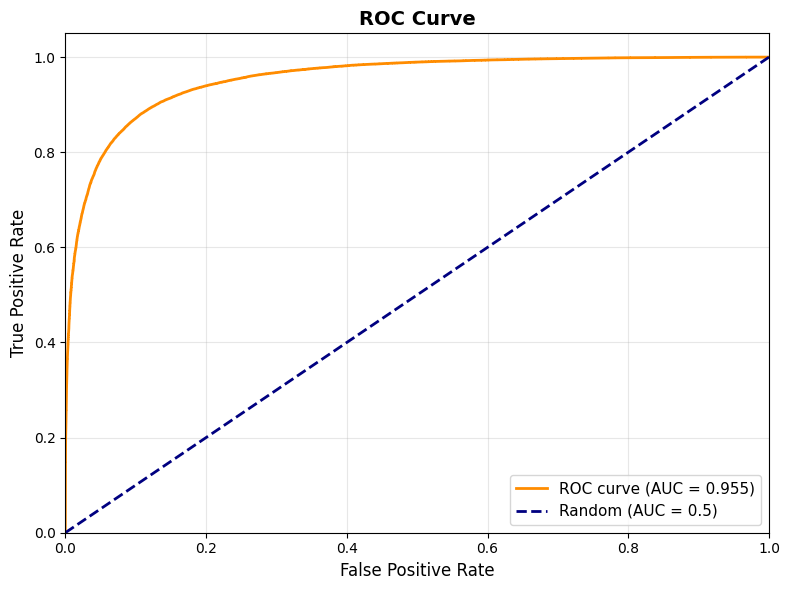

ROC-AUC Score: 0.9547

SHAP Analysis

1. SHAP Summary Plot (Feature Importance)


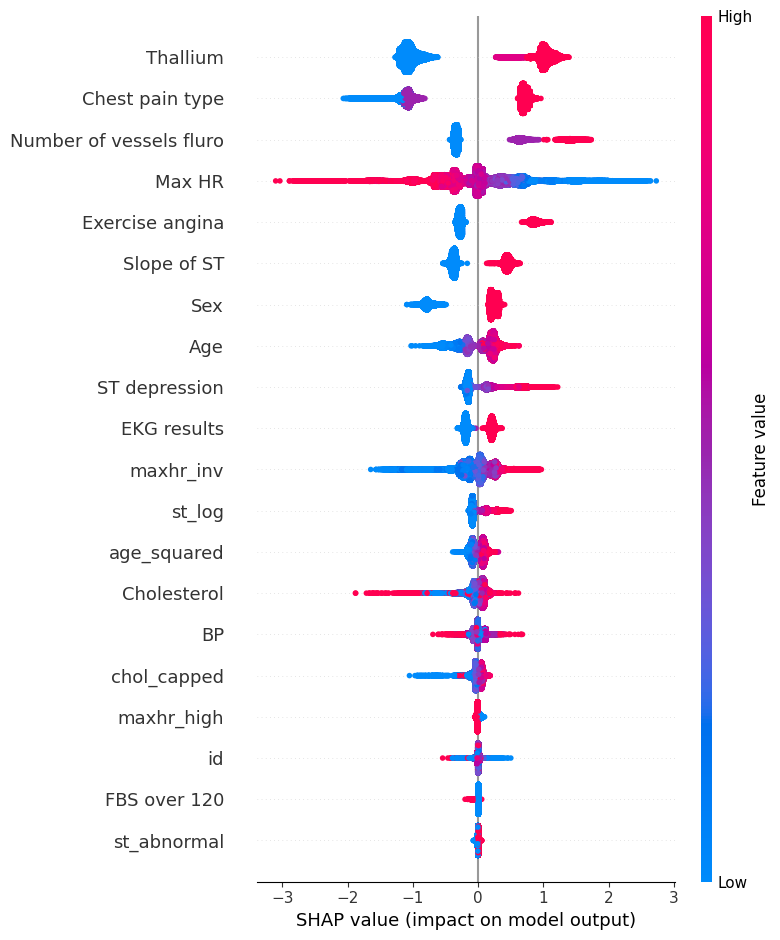


2. SHAP Feature Importance (Mean |SHAP value|)


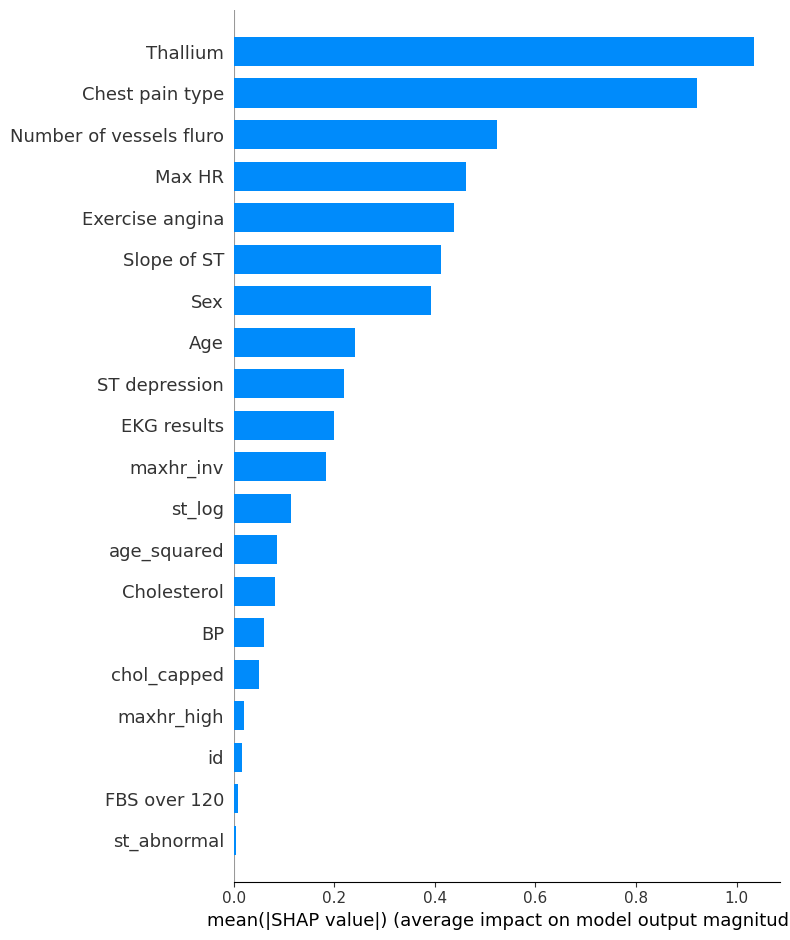


3. SHAP Force Plot (Single Prediction)



4. SHAP Dependence Plot (Top Features)


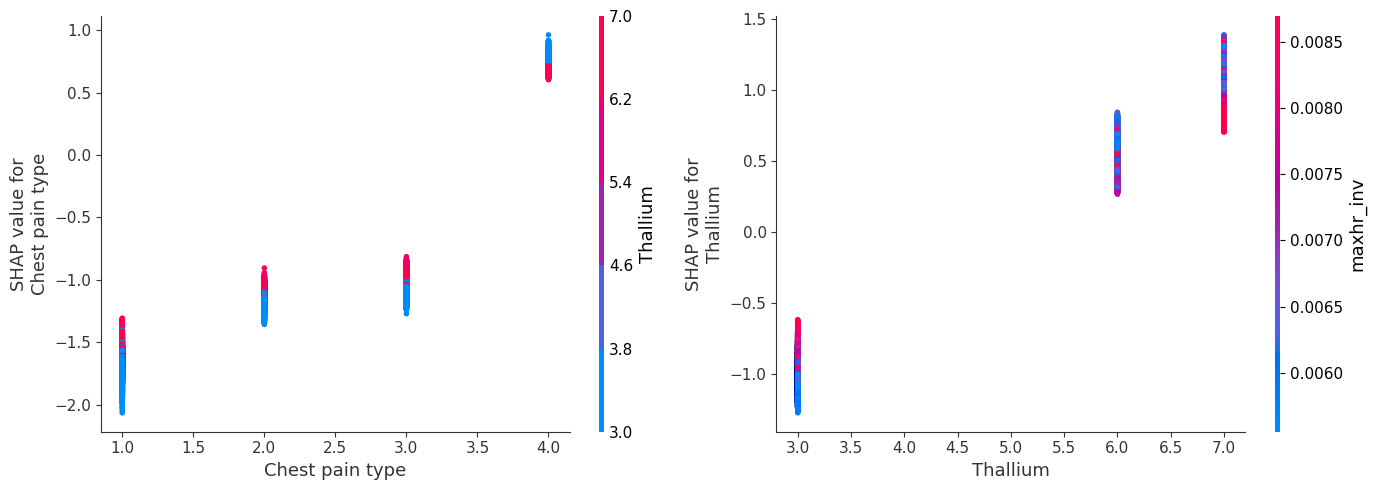

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import shap

# ========================================
# 1. ROC 곡선
# ========================================
def plot_roc_curve(model, X_test, y_test):
    """ROC 곡선 시각화"""
    
    # 예측 확률
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC curve 계산
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # 시각화
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random (AUC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"ROC-AUC Score: {roc_auc:.4f}")

# ========================================
# 2. SHAP 분석
# ========================================
def shap_analysis(model, X_train, X_test, max_display=20):
    """SHAP 분석 및 시각화"""
    
    # SHAP Explainer 생성
    explainer = shap.TreeExplainer(model)
    
    # SHAP values 계산 (테스트 데이터)
    shap_values = explainer.shap_values(X_test)
    
    # 1. Summary Plot (Feature Importance)
    print("\n1. SHAP Summary Plot (Feature Importance)")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, max_display=max_display, show=False)
    plt.tight_layout()
    plt.show()
    
    # 2. Bar Plot (평균 절대값)
    print("\n2. SHAP Feature Importance (Mean |SHAP value|)")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, plot_type="bar", 
                      max_display=max_display, show=False)
    plt.tight_layout()
    plt.show()
    
    # 3. 개별 예측 설명 (첫 번째 샘플)
    print("\n3. SHAP Force Plot (Single Prediction)")
    shap.initjs()  # Jupyter용
    display(shap.force_plot(
        explainer.expected_value, 
        shap_values[0], 
        X_test.iloc[0]
    ))
    
    # 4. Dependence Plot (상위 2개 피처)
    print("\n4. SHAP Dependence Plot (Top Features)")
    top_features = X_test.columns[
        np.abs(shap_values).mean(0).argsort()[-2:]
    ]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, feature in enumerate(top_features):
        shap.dependence_plot(
            feature, shap_values, X_test, 
            ax=axes[i], show=False
        )
    plt.tight_layout()
    plt.show()


# ========================================
# 3. 한 번에 실행
# ========================================
def full_analysis(model, X_train, X_test, y_test):
    """ROC + SHAP 전체 분석"""
    
    print("="*60)
    print("ROC Curve Analysis")
    print("="*60)
    plot_roc_curve(model, X_test, y_test)
    
    print("\n" + "="*60)
    print("SHAP Analysis")
    print("="*60)
    shap_analysis(model, X_train, X_test)

# 사용
full_analysis(final_model, X_train, X_test, y_test)

### 1. Summary Plot
- Y축 : 피처 중요도순
- X축 : SHAP value
    - 양수(+) : 심장병 확률 상승
    - 음수(-) : 심장병 확률 하락
- 색상 : 피처 값
    - 빨강 : 높은 값
    - 파랑 : 낮은값

---
#### 주요피처 설명

1. Thallium
    - 탈륨이 높으면(빨간점) 심장병 확률이 높다.(오른쪽(+))
2. Chest pain type
    - 가슴 통증 단계가 4단계면 심장병 확률이 높다. (무증상일때 심장병 확률이 높다)
3. Max HR
    - 최대 심박수가 높을 수록 안전하다.(역관계)

#### 엔지니어링 피처 검증
- maxhr_inv: 중요도 중간 (효과 있음)
- st_log: 중요도 중간 (효과 있음)
- age_squared: 중요도 낮음 (Age보다 약함)
- chol_capped: 중요도 낮음 (Cholesterol과 비슷)

- maxhr_high, st_abnormal, FBS over 120: 거의 무용

---

### 2. Force Plot
- Base value: 2.455 (평균 예측값, log-odds)
- Final output: -1.09 (이 환자 예측, log-odds)

- 빨강 화살표: 심장병 확률 ↑
- 파랑 화살표: 심장병 확률 ↓

---

#### 핵심 인사이트
1. 중요 피처 TOP 5
- 탈륨, 가슴통증, Number of vessels fluro, 최대심박수, Exercise angina

2. 엔지니어링 효과
- 효과있음
    - maxhr_inv (MaxHR 역수)
    - st_log (로그 변환)

- 효과 약함:
    - age_squared (Age만으로 충분)
    - chol_capped (Cholesterol과 중복)
    - 이진화 피처들 (거의 무용)

---

### 3. Dependence Plot
1. 왼쪽 그림
    - X축: Chest pain type (1, 2, 3, 4)
    - Y축: SHAP value
    - 색상: Thallium 값

    - 패턴:
        - 타입 1, 2, 3: SHAP value 음수 (안전)
        - 타입 4: SHAP value 양수 (위험)
        - Thallium 높으면(빨강) 더 위험
    - 해석
        - 무증상 + 탈륨 높음 = 최악, 전형적 협심증(1) + 탈륨 낮음 = 안전
        